# Data Investigation Notebook

### Setup

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

from dataset_generator.single_transactions_dataset import SingleTransactionsDataset
from dataset_generator.feature_extraction import (
    NODE_TYPE_FEATURE_DIMS, SINGLE_CHAIN_LABEL_MAP,
    IN_DEGREE_INDEX, OUT_DEGREE_INDEX, AMOUNTS_INDEX,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

dataset = SingleTransactionsDataset(root="../datasets/single")
print(f"Dataset size: {len(dataset)} graphs")

/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Exporting data from database to CSV files... 
Dataset size: 1778 graphs


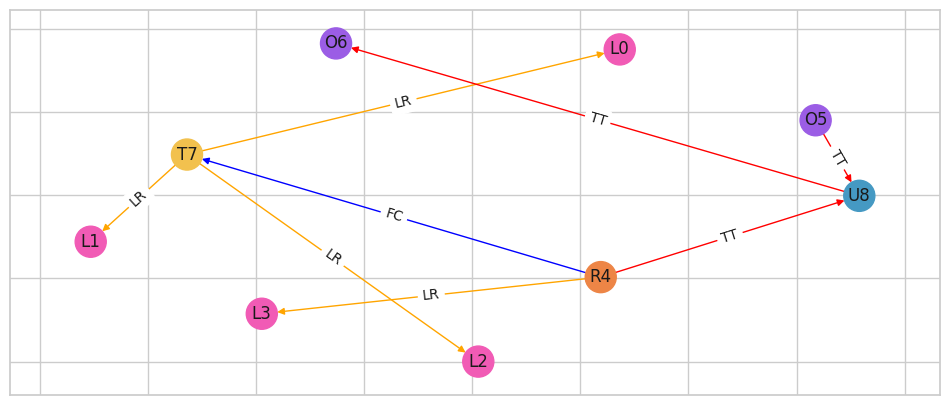

In [ ]:
from dataset_generator.visualizer import visualize_graph

# Ronin Bridge Attack
x = "0x2619570088683e6cc3a38d93c3d98899e5783864e15525d5f5810c11189ba6cb"  # Replace with an actual transaction hash from the dataset
graph = dataset.get_by_tx_hash(x)

# Visualize the graph
visualize_graph(graph)

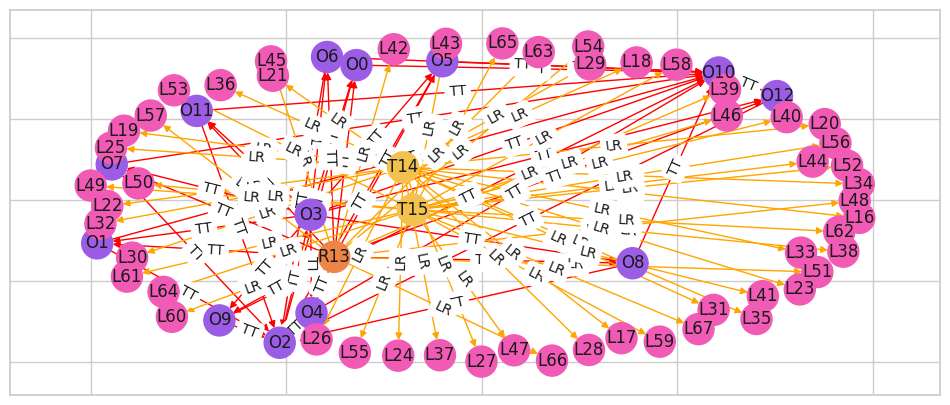

In [11]:
from dataset_generator.visualizer import visualize_graph

# Nomad Bridge Attack
x = "0x22336a9c76a28b24bb9c74c3b238655d836d501b38ea129ce0515af3f4bbb117"  # Replace with an actual transaction hash from the dataset
graph = dataset.get_by_tx_hash(x)

# Visualize the graph
visualize_graph(graph)

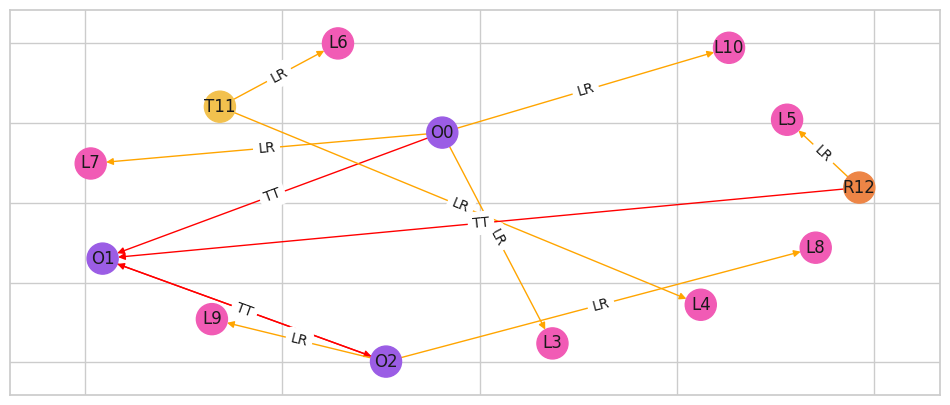

In [ ]:
from dataset_generator.visualizer import visualize_graph

# Nomad Bridge Attack
x = "0x0d0fb915d7d0e4878574e3128bdbaabbf0d47e47f499fb482fbac3c51a112476"  # Replace with an actual transaction hash from the dataset
graph = dataset.get_by_tx_hash(x)

# Visualize the graph
visualize_graph(graph)

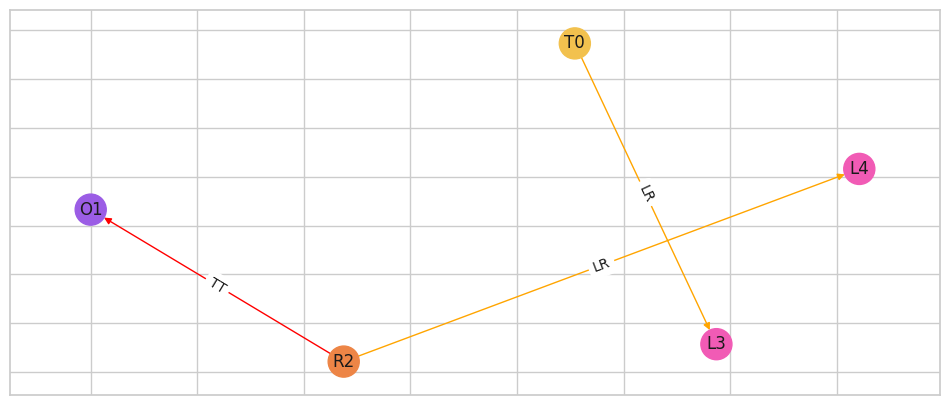

In [ ]:
from dataset_generator.visualizer import visualize_graph

# Nomad attack on "Receive"
x = "0x657a28015280bb0d92ef17c0e6e6b3542fbd1481a994eece2696bbf581de1c66"  # Replace with an actual transaction hash from the dataset
graph = dataset.get_by_tx_hash(x)

# Visualize the graph
visualize_graph(graph)

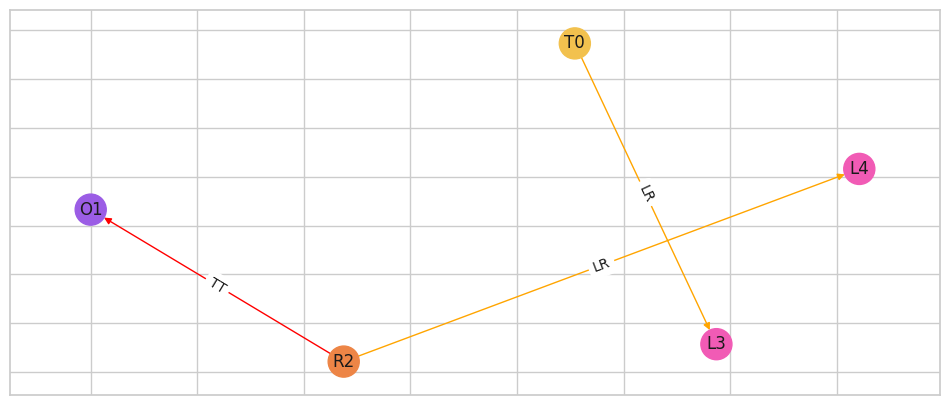

In [ ]:
from dataset_generator.visualizer import visualize_graph

# Normal Nomad Target Chain Tx
x = "0x2825ac736830b4ced86aef1a42a2cd92e9e730fa904c503fda4c5ac8ede64708"  # Replace with an actual transaction hash from the dataset
graph = dataset.get_by_tx_hash(x)

# Visualize the graph
visualize_graph(graph)

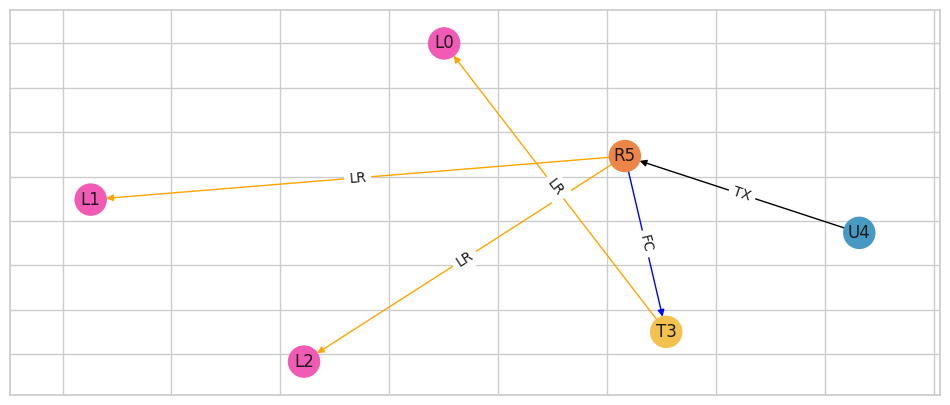

In [ ]:
from dataset_generator.visualizer import visualize_graph

# Normal Nomad Deposit Tx
x = "0xc7ccfba1f99b7bbf607f6e3fd815d312a5721a98fbdbc863f2115e8a08924c12"  # Replace with an actual transaction hash from the dataset
graph = dataset.get_by_tx_hash(x)

# Visualize the graph
visualize_graph(graph)

In [4]:
ALL_NODE_TYPES = list(NODE_TYPE_FEATURE_DIMS.keys())
ALL_EDGE_RELS = [
    "transaction", "token_transfer", "token_auth",
    "function_call", "log_relation", "cross_chain_relation",
]

# Build a unified int→label-string map (single-chain values take priority for shared keys)
INT_TO_LABEL = {}
INT_TO_LABEL.update({v: k for k, v in SINGLE_CHAIN_LABEL_MAP.items()})


def collect_graph_stats(ds):
    records = []
    for i in tqdm(range(len(ds)), desc="Collecting stats"):
        data = ds[i]
        label_int = data.y.item()
        label_str = getattr(data, "y_str", INT_TO_LABEL.get(label_int, str(label_int)))
        tx_hash = getattr(data, "tx_hash", "unknown")
        bridge = getattr(data, "bridge", "unknown")

        node_counts = {
            f"n_{nt}": (data[nt].num_nodes if nt in data.node_types else 0)
            for nt in ALL_NODE_TYPES
        }
        total_nodes = sum(node_counts.values())

        edge_counts: dict = defaultdict(int)
        for src, rel, dst in data.edge_types:
            edge_counts[rel] += data[(src, rel, dst)].edge_index.shape[1]

        records.append({
            "idx": i,
            "label_int": label_int,
            "label_str": label_str,
            "tx_hash": tx_hash,
            "bridge": bridge,
            "total_nodes": total_nodes,
            "total_edges": sum(edge_counts.values()),
            "num_node_types_present": sum(1 for v in node_counts.values() if v > 0),
            "num_edge_rels_present": len(edge_counts),
            **node_counts,
            **{f"e_{k}": v for k, v in edge_counts.items()},
        })

    df = pd.DataFrame(records)
    for et in ALL_EDGE_RELS:
        col = f"e_{et}"
        if col not in df.columns:
            df[col] = 0
        df[col] = df[col].fillna(0).astype(int)
    return df


stats_df = collect_graph_stats(dataset)
print(stats_df.shape)
stats_df.head(10)

(1778, 21)


,idx,label_int,label_str,tx_hash,bridge,total_nodes,total_edges,num_node_types_present,num_edge_rels_present,n_user,...,n_token,n_other_account,n_log_event,n_validator,e_token_transfer,e_log_relation,e_function_call,e_transaction,e_token_auth,e_cross_chain_relation
0,0,0,normal,0x18e856259084630635801f6ff78ad4ca72251b196e23...,omnibridge,7,6,4,3,1,...,1,0,3,0,1,3,2,0,0,0
1,1,0,normal,0x0af04166ad5800c2fd44554ec830d53a14a42aaa0cf9...,omnibridge,7,6,4,3,1,...,1,0,3,0,1,3,2,0,0,0
2,2,0,normal,0xe6593624fc06e287deb7c347098780187a267542f260...,ronin,5,4,4,3,1,...,1,0,2,0,1,2,1,0,0,0
3,3,0,normal,0xf06a0046825af4a536f3ac94d23842635fb721b9aeb0...,ronin,7,7,5,4,1,...,1,1,3,0,2,3,1,1,0,0
4,4,0,normal,0x9f5a73a87b1efd1012816a3216d2856a35bdd44bc99b...,ronin,5,5,4,4,1,...,1,0,2,0,1,2,1,1,0,0
5,5,0,normal,0x0f76111ffb9afdc6f123f47bb6e681aa1f17baf2b0c0...,ronin,7,7,5,4,1,...,1,1,3,0,2,3,1,1,0,0
6,6,0,normal,0xcc381169e4ce23251abdd0869a7dba0679aff5f00661...,ronin,5,4,4,3,1,...,1,0,2,0,1,2,1,0,0,0
7,7,0,normal,0xf44b44284214e1a41ccbc1925203e34c32fde3a1f791...,ronin,7,7,5,4,1,...,1,1,3,0,2,3,1,1,0,0
8,8,0,normal,0xf343a969f8f633493dc1149e28f76695e0d6b35ba1c2...,ronin,5,4,4,3,1,...,1,0,2,0,1,2,1,0,0,0
9,9,0,normal,0x819c5623e289257621110aae047e120d8cdda1a18d1d...,ronin,7,7,5,4,1,...,1,1,3,0,2,3,1,1,0,0


In [5]:
stats_df[stats_df["bridge"] == "nomad"].head(10)

,idx,label_int,label_str,tx_hash,bridge,total_nodes,total_edges,num_node_types_present,num_edge_rels_present,n_user,...,n_token,n_other_account,n_log_event,n_validator,e_token_transfer,e_log_relation,e_function_call,e_transaction,e_token_auth,e_cross_chain_relation
450,450,0,normal,0xc7ccfba1f99b7bbf607f6e3fd815d312a5721a98fbdb...,nomad,6,6,4,4,1,...,1,0,3,0,1,3,1,1,0,0
451,451,0,normal,0x8d051698559301a7053fb799d80d39916443f62f9c87...,nomad,8,9,4,4,1,...,1,0,5,0,2,5,1,1,0,0
452,452,0,normal,0xe4f33223821784fd4ed795c1adeee30ade87d4215c73...,nomad,8,9,4,4,1,...,1,0,5,0,2,5,1,1,0,0
453,453,0,normal,0x59a5bb860f89ae2642df50b30e6fe247e4881ed2a7f4...,nomad,8,9,4,4,1,...,1,0,5,0,2,5,1,1,0,0
454,454,0,normal,0xe497963ee3726e46afb35657f2e44f0afda468d440dd...,nomad,8,9,4,4,1,...,1,0,5,0,2,5,1,1,0,0
455,455,0,normal,0x42fd6cc9b75807783e1837f216383e015b1872787190...,nomad,8,9,4,4,1,...,1,0,5,0,2,5,1,1,0,0
456,456,0,normal,0x680c26edde8c1cc455e86cc0c548529d77b8bc0ca936...,nomad,6,6,4,4,1,...,1,0,3,0,1,3,1,1,0,0
457,457,0,normal,0xbba6ac6e70bf406268086b4e8cda7959a7be8d6e9d9d...,nomad,8,9,4,4,1,...,1,0,5,0,2,5,1,1,0,0
458,458,0,normal,0xf99101190e757996ff4ddd8d016f1e6e30222115a0cf...,nomad,8,9,4,4,1,...,1,0,5,0,2,5,1,1,0,0
459,459,0,normal,0x621c78d63fe4553c293c84af9c4141083912e777b6bf...,nomad,8,9,4,4,1,...,1,0,5,0,2,5,1,1,0,0


## 1. Label Distribution (Imbalance Audit)
Quantifies the imbalance across all label strings.

           count    pct
label_str              
anomaly      166   9.34
normal      1612  90.66


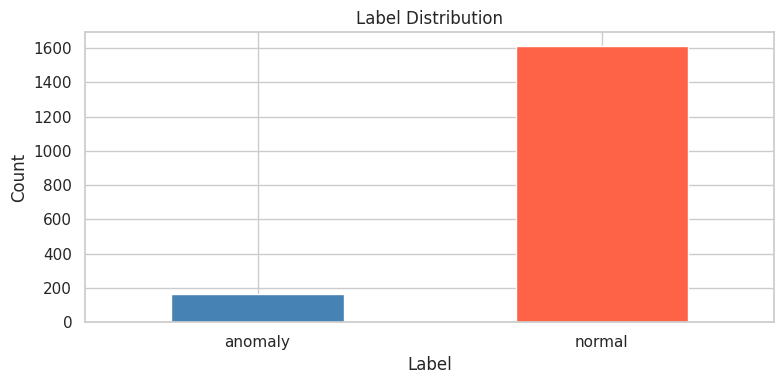

In [6]:
label_counts = stats_df["label_str"].value_counts().sort_index()
label_pct = (label_counts / label_counts.sum() * 100).round(2)

summary = pd.DataFrame({"count": label_counts, "pct": label_pct})
print(summary)

ax = summary["count"].plot(kind="bar", figsize=(8, 4), color=["steelblue", "tomato"])
ax.set_title("Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

*Old text (before converging to single-chain only):*

Because anomaly labels are so low, cross-entropy alone may not be enough. It's necessary to consider oversampling techniques or undersampling.

At the same time, using cross-chain graphs along with single chain graphs, when cross-chain graphs by definition are not anomalous, may cause the model to learn to predict "normal" for all cross-chain graphs, and thus fail to learn the more subtle patterns that distinguish anomalous single-chain graphs from normal single-chain graphs. This could lead to poor generalization on single-chain graphs. -> (GOOD FOR A CITATION?)

**What about adding the "single-chain" parts of the CCTX data as normal examples?** 

This would increase the number of normal examples, thus making imbalance worse, and would not provide any new discriminative signal, since most normal single-chain cases can actually be part of potential CCTX transactions, just without the cross-chain component, due to not all chains being involved in the data extraction.

**Result:** Focus only on single-chain graphs, forget about cross-chain. Add oversampling techniques later on, after establishing a strong baseline.

## 2. Bridge × Label Distribution
Cross-tab and anomaly-rate per bridge; tells you if Nomad/Ronin/OmniBridge drive the imbalance differently

label_str   anomaly  normal
bridge                     
nomad           165    1163
omnibridge        0     394
ronin             1      55


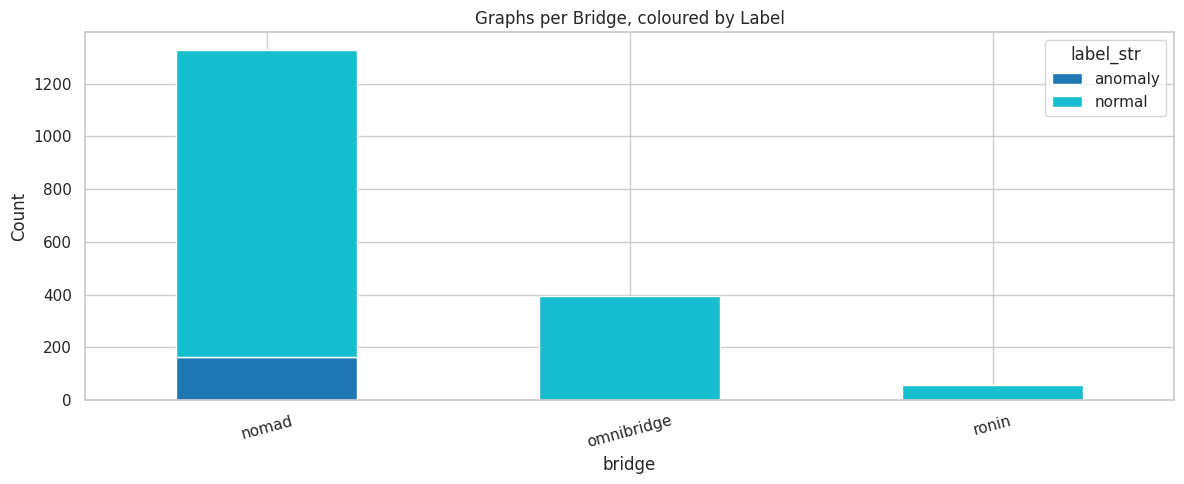


Anomaly rate per bridge:
label_str   _total  anomaly_rate
bridge                          
nomad         1328      0.124247
ronin           56      0.017857
omnibridge     394      0.000000


In [7]:
bridge_label = pd.crosstab(stats_df["bridge"], stats_df["label_str"])
print(bridge_label)

bridge_label.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab10")
plt.title("Graphs per Bridge, coloured by Label")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

bridge_label["_total"] = bridge_label.sum(axis=1)
anomaly_cols = [c for c in bridge_label.columns if "anomaly" in c.lower()]
bridge_label["anomaly_rate"] = bridge_label[anomaly_cols].sum(axis=1) / bridge_label["_total"]
print("\nAnomaly rate per bridge:")
print(bridge_label[["_total", "anomaly_rate"]].sort_values("anomaly_rate", ascending=False))

Nomad accounts for wayyy more anomalies (and cases) than the other two bridges. This might mean that the model may learn to predict various different types of normal cases for Ronin and OmniBridge.

**Potential solutions:** 
- Maybe stratify train/val/test results into label&bridge, instead of just label
- Use synthetic augmentation, BUT
    - First learn what an anomaly looks like structurally before doing so
    - Synthetically augment, if possible, by transferring what makes an anomaly on Nomad, and replicating that on Ronin (though this is risky)
- If possible, extend data with other bridges (not just Ronin) that contain a fair share of anomaly data
    - If not, the scope of the thesis will have to be reduced into "just basing off of the Nomad attack", instead of claiming to be "bridge-agnostic"...

## 3. Graph Size Distribution by Label

/tmp/ipykernel_20535/1896761848.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_df, x="label_str", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_20535/1896761848.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_df, x="label_str", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_20535/1896761848.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_df, x="label_str", y=col, ax=ax, palette="Set2")


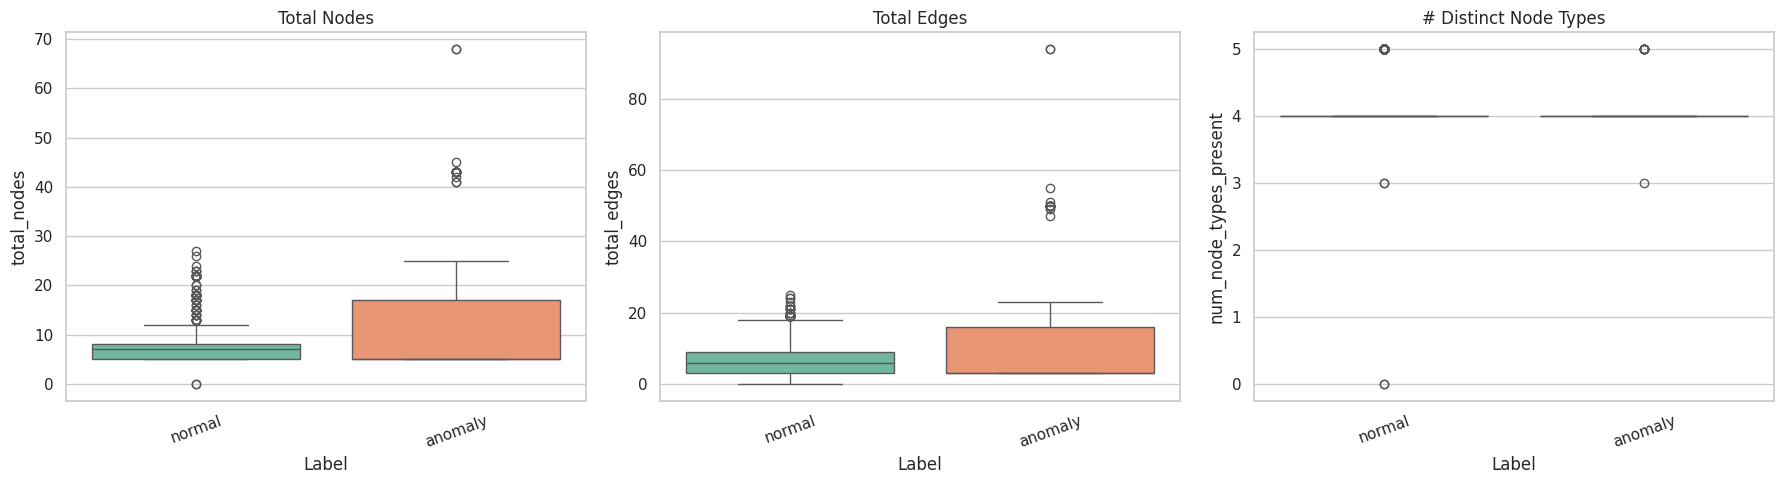

          total_nodes                                        total_edges  \
                count  mean   std  min  25%  50%   75%   max       count   
label_str                                                                  
anomaly         166.0  14.8  14.4  5.0  5.0  5.0  17.0  68.0       166.0   
normal         1612.0   7.3   3.7  0.0  5.0  7.0   8.0  27.0      1612.0   

                                                  
           mean   std  min  25%  50%   75%   max  
label_str                                         
anomaly    14.7  18.5  3.0  3.0  3.0  16.0  94.0  
normal      6.2   4.1  0.0  3.0  6.0   9.0  25.0  


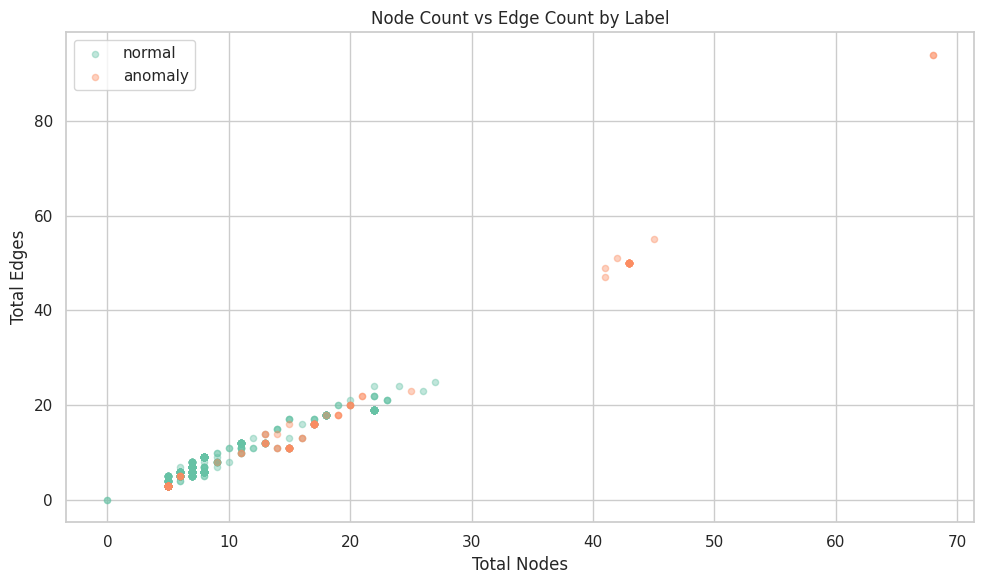

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ["total_nodes", "total_edges", "num_node_types_present"],
    ["Total Nodes", "Total Edges", "# Distinct Node Types"],
):
    sns.boxplot(data=stats_df, x="label_str", y=col, ax=ax, palette="Set2")
    ax.set_title(title)
    ax.set_xlabel("Label")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print(stats_df.groupby("label_str")[["total_nodes", "total_edges"]].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 6))
labels_unique = stats_df["label_str"].unique()
palette = dict(zip(labels_unique, sns.color_palette("Set2", len(labels_unique))))
for lbl in labels_unique:
    sub = stats_df[stats_df["label_str"] == lbl]
    ax.scatter(sub["total_nodes"], sub["total_edges"], alpha=0.4, label=lbl,
               color=palette[lbl], s=20)
ax.set_xlabel("Total Nodes")
ax.set_ylabel("Total Edges")
ax.set_title("Node Count vs Edge Count by Label")
ax.legend()
plt.tight_layout()
plt.show()

Some anomalies (but not all) have a much larger amount of nodes and edges than normal cases, however, the boxplot shows that there is a 40-50% overlap in the interquartile ranges of the two distributions, which means that graph size alone is not a sufficient feature to distinguish between anomalous and normal cases. 

This suggests that while graph size may be a useful feature for anomaly detection, it should be used in conjunction with other features to improve the model's performance.

## 4. Node Type Presence by Label

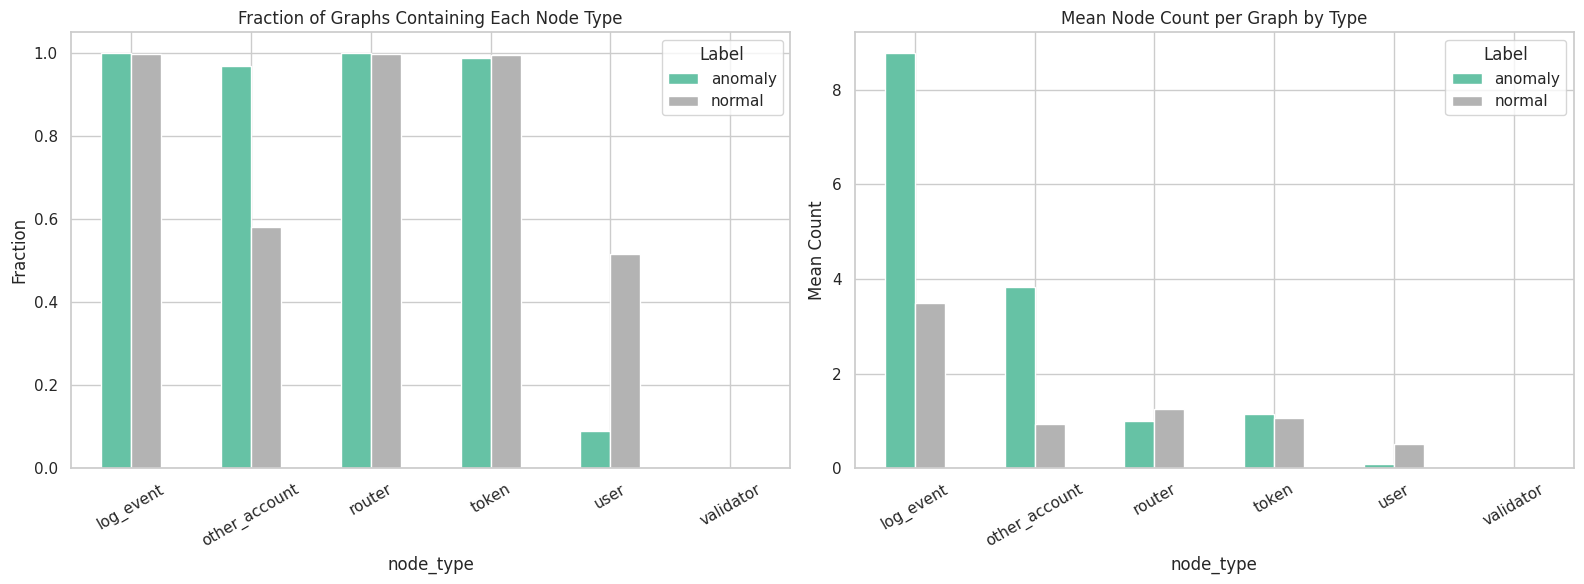

In [10]:
presence = []
for lbl, grp in stats_df.groupby("label_str"):
    for nt in ALL_NODE_TYPES:
        col = f"n_{nt}"
        presence.append({
            "label": lbl,
            "node_type": nt,
            "fraction_present": (grp[col] > 0).mean(),
            "mean_count": grp[col].mean(),
        })

pres_df = pd.DataFrame(presence)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pres_df.pivot(index="node_type", columns="label", values="fraction_present").plot(
    kind="bar", ax=axes[0], colormap="Set2"
)
axes[0].set_title("Fraction of Graphs Containing Each Node Type")
axes[0].set_ylabel("Fraction")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Label")

pres_df.pivot(index="node_type", columns="label", values="mean_count").plot(
    kind="bar", ax=axes[1], colormap="Set2"
)
axes[1].set_title("Mean Node Count per Graph by Type")
axes[1].set_ylabel("Mean Count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Label")

plt.tight_layout()
plt.show()

- Anomaly cases have a larger presence of nodes with types "other_account" and less presence of "user" nodes in their graphs.
- On average, anomalous cases have a higher number of "log_event" nodes and "other_account" nodes than normal cases, thus the model may learn to associate higher presence of these node types with anomalous cases. This correlates with the fact that we're using differential meta-path extraction, which focuses on the presence of certain node types and their interactions as key features for anomaly detection.

### 4.1. Edge Type Presence by Label

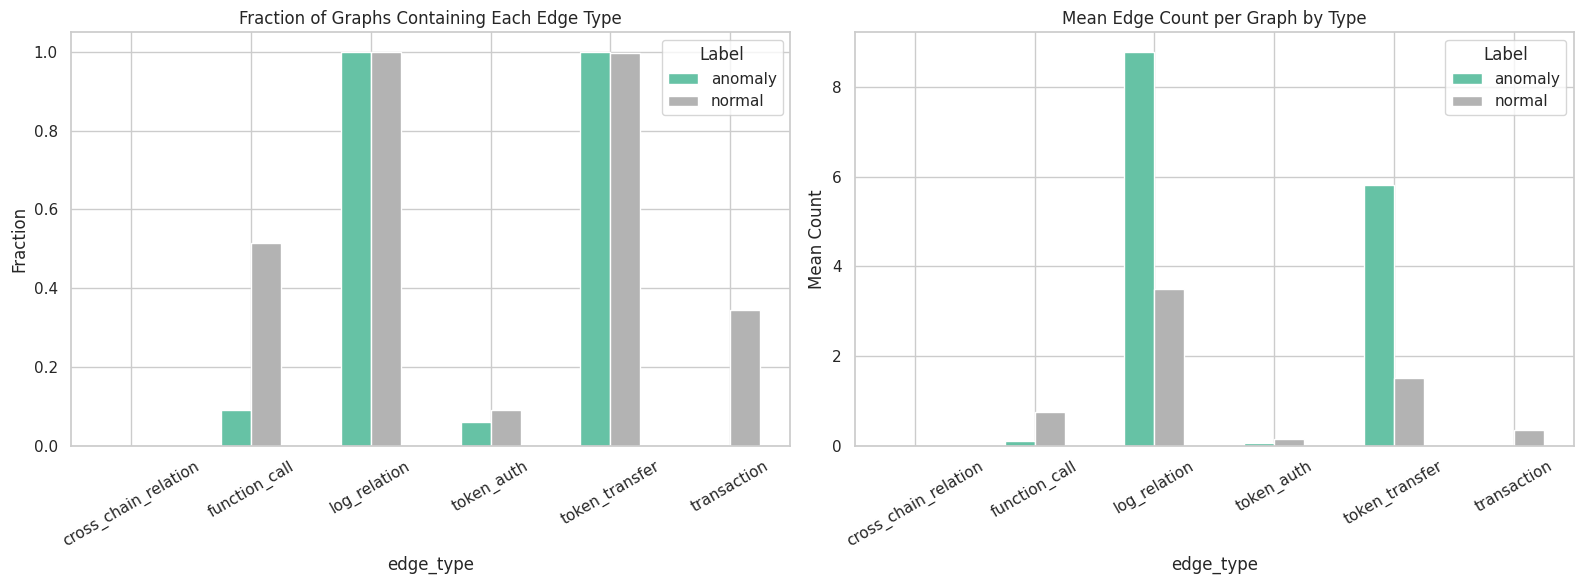

In [12]:
edge_presence = []
for lbl, grp in stats_df.groupby("label_str"):
    for rel in ALL_EDGE_RELS:
        col = f"e_{rel}"
        edge_presence.append({
            "label": lbl,
            "edge_type": rel,
            "fraction_present": (grp[col] > 0).mean(),
            "mean_count": grp[col].mean(),
        })

edge_pres_df = pd.DataFrame(edge_presence)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

edge_pres_df.pivot(index="edge_type", columns="label", values="fraction_present").plot(
    kind="bar", ax=axes[0], colormap="Set2"
)
axes[0].set_title("Fraction of Graphs Containing Each Edge Type")
axes[0].set_ylabel("Fraction")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Label")

edge_pres_df.pivot(index="edge_type", columns="label", values="mean_count").plot(
    kind="bar", ax=axes[1], colormap="Set2"
)
axes[1].set_title("Mean Edge Count per Graph by Type")
axes[1].set_ylabel("Mean Count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Label")

plt.tight_layout()
plt.show()

- Anomaly cases have a smaller presence of edges with types "function_call" and almost no presence of "transaction" edges in their graphs, compared to 40% of normal cases.
- On average, anomalous cases have a higher number of "log_relation" nodes and "token_transfer" nodes than normal cases, thus the model may learn to associate higher presence of these node types with anomalous cases. This correlates with the fact that we're using differential meta-path extraction, which focuses on the presence of certain node types and their interactions as key features for anomaly detection.

## 5. Feature Distributions — Log Events

Distributions of degree, event_order, amount_usd, args_num, event-type bar charts, and blockchain-stage breakdown, all split normal vs anomaly

`log_event` nodes carry the richest semantic information (25 features):
- **Index 0 / 1**: in_degree / out_degree
- **Index 2-4**: blockchain stage (source / destination / offchain, one-hot)
- **Index 5-8**: blockchain identity (4-bit binary)
- **Index 9**: event_order (position in transaction sequence)
- **Indices 10-13**: event_type (4-bit binary)
- **Index 14 / 15**: args_num / input_size
- **Index 16**: amount_usd (log1p-normalised)
- **Indices 17-24**: token symbol hash

  normal    :    5,631 log_event nodes
  anomaly   :    1,457 log_event nodes


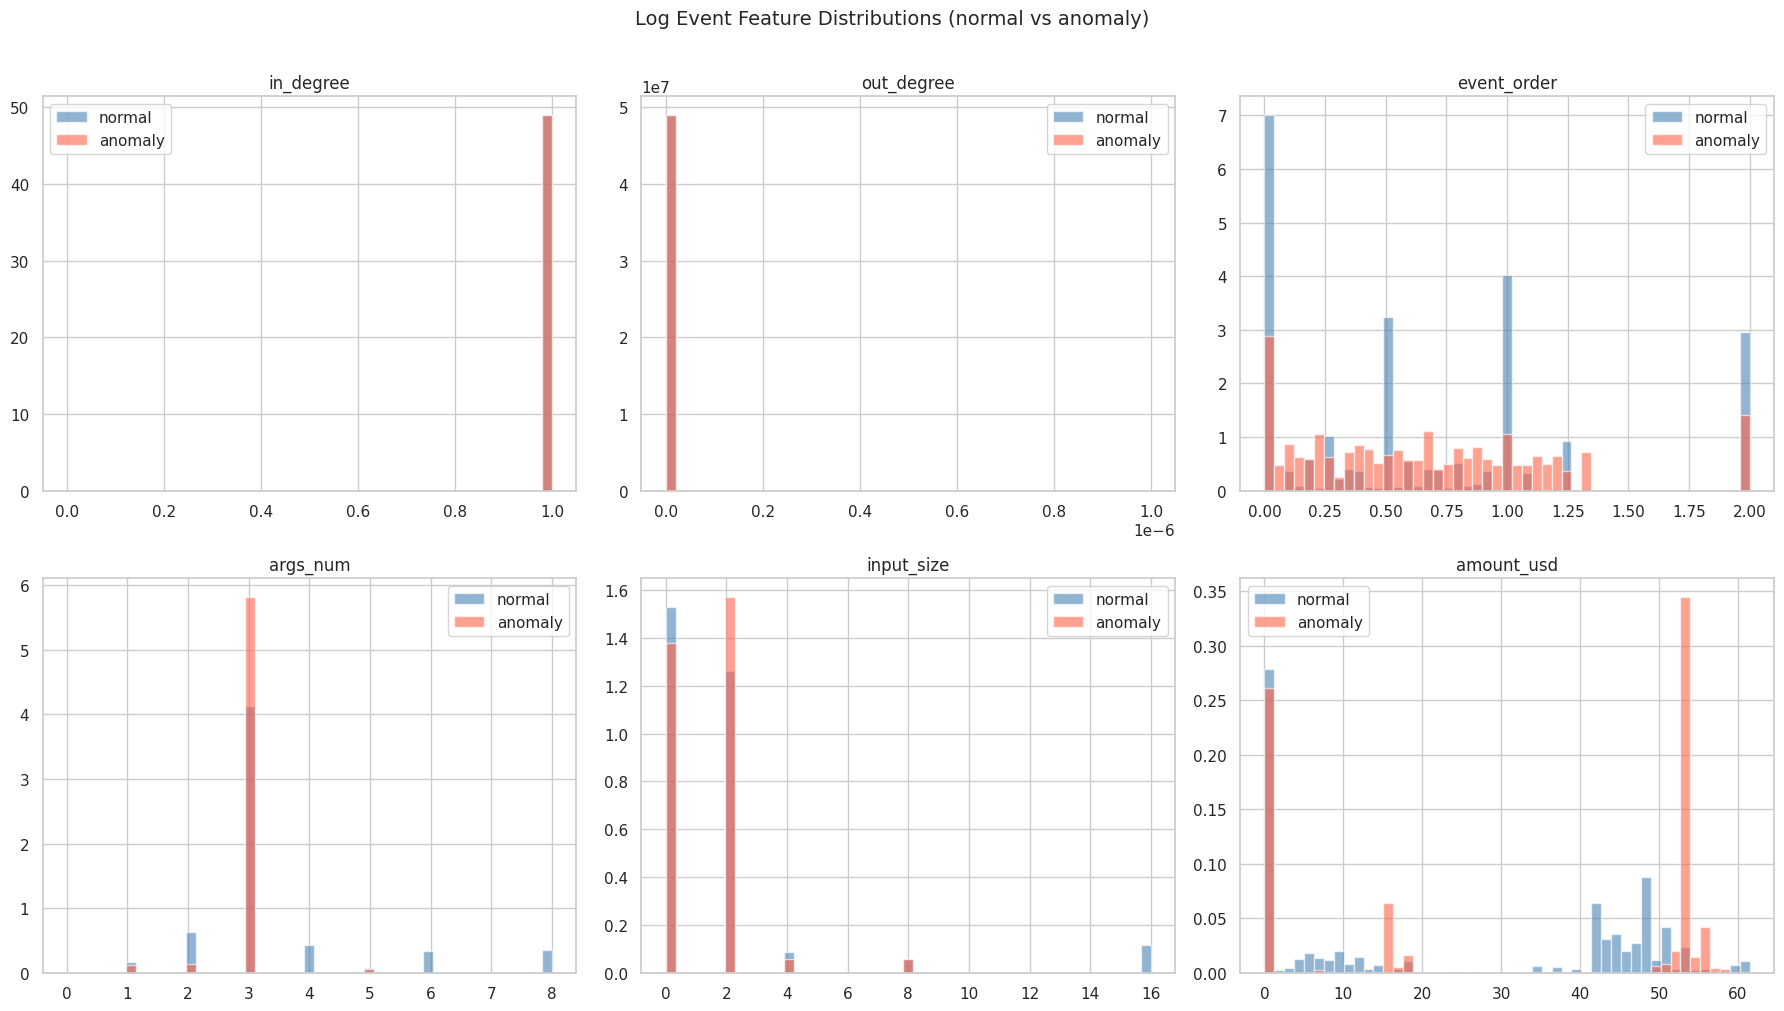

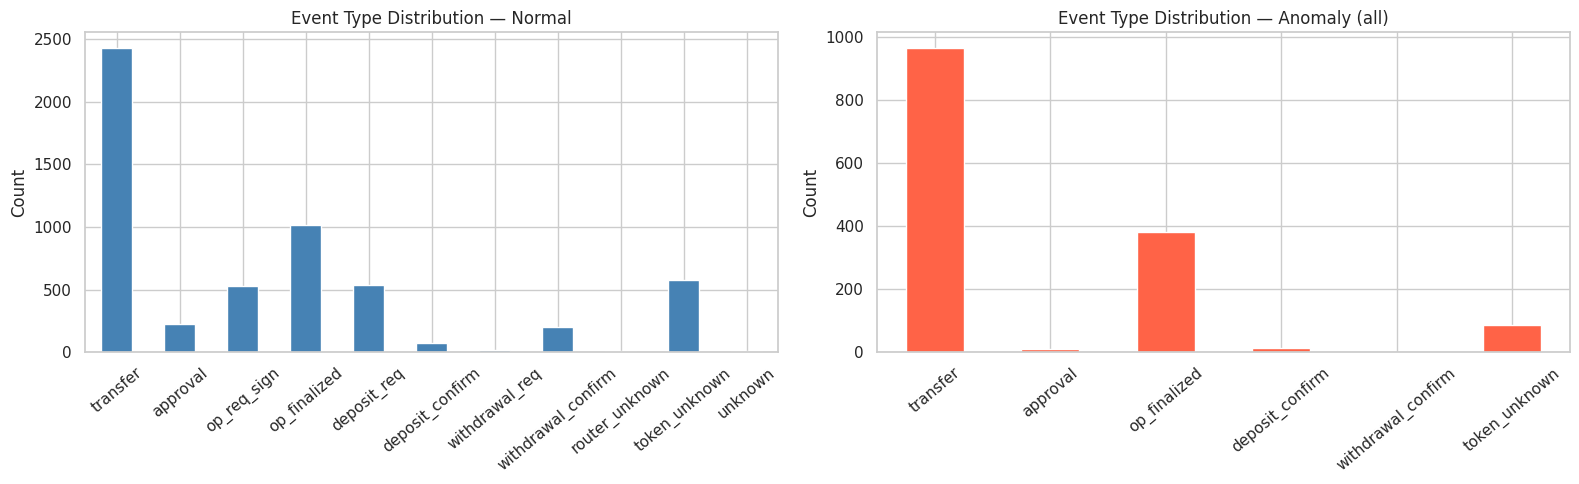

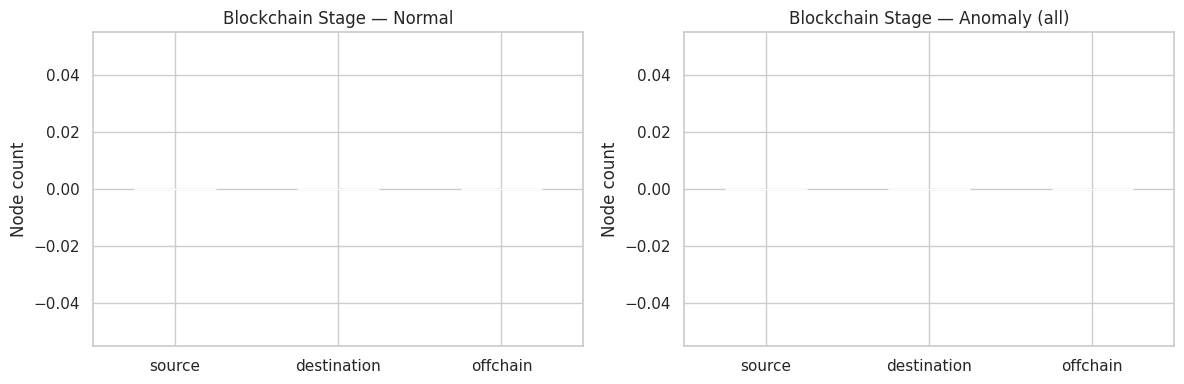

In [13]:
log_feats_by_label: dict = defaultdict(list)

for i in range(len(dataset)):
    data = dataset[i]
    label_str = getattr(data, "y_str", "")
    if "log_event" not in data.node_types:
        continue
    x = data["log_event"].x
    if x.numel() == 0:
        continue
    log_feats_by_label[label_str].append(x.numpy())

mats = {lbl: np.concatenate(arrs, axis=0) for lbl, arrs in log_feats_by_label.items() if arrs}
for lbl, mat in mats.items():
    print(f"  {lbl:10s}: {mat.shape[0]:>8,} log_event nodes")

# Feature names
log_feat_names = (
    ["in_degree", "out_degree"]
    + [f"stage_{i}" for i in range(3)]
    + [f"blockchain_{i}" for i in range(4)]
    + ["event_order"]
    + [f"event_type_{i}" for i in range(4)]
    + ["args_num", "input_size", "amount_usd"]
    + [f"token_sym_{i}" for i in range(8)]
)

# ── Continuous feature distributions ──────────────────────────────────────────
key_idx = [0, 1, 9, 14, 15, 16]
key_names = [log_feat_names[i] for i in key_idx]

normal_mat = mats.get("normal", np.empty((0, 25)))
anomaly_arrs = [mats[k] for k in mats if "anomaly" in k]
anomaly_mat = np.concatenate(anomaly_arrs, axis=0) if anomaly_arrs else np.empty((0, 25))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fi, fname in zip(axes.ravel(), key_idx, key_names):
    all_vals = np.concatenate([normal_mat[:, fi], anomaly_mat[:, fi]])
    vmax = np.percentile(all_vals, 99) if len(all_vals) else 1
    bins = np.linspace(0, max(vmax, 1e-6), 50)
    ax.hist(normal_mat[:, fi].clip(0, vmax), bins=bins, alpha=0.6, label="normal", density=True, color="steelblue")
    ax.hist(anomaly_mat[:, fi].clip(0, vmax), bins=bins, alpha=0.6, label="anomaly", density=True, color="tomato")
    ax.set_title(fname)
    ax.legend()
plt.suptitle("Log Event Feature Distributions (normal vs anomaly)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# ── Event type distribution ────────────────────────────────────────────────────
EVENT_INT_TO_NAME = {
    0: "transfer", 1: "approval", 2: "burn", 3: "mint",
    4: "op_req_sign", 5: "op_finalized",
    8: "deposit_req", 9: "deposit_confirm",
    10: "withdrawal_req", 11: "withdrawal_confirm",
    12: "router_unknown", 13: "token_unknown", 15: "unknown",
}

def bits_to_int(matrix, start=10, length=4):
    weights = np.array([8, 4, 2, 1])
    return (matrix[:, start : start + length] * weights).sum(axis=1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (lbl, mat) in zip(axes, [("Normal", normal_mat), ("Anomaly (all)", anomaly_mat)]):
    if mat.shape[0] == 0:
        ax.set_title(f"Event Type — {lbl} (no data)")
        continue
    counts = pd.Series(bits_to_int(mat)).value_counts().sort_index()
    counts.index = [EVENT_INT_TO_NAME.get(i, str(i)) for i in counts.index]
    counts.plot(kind="bar", ax=ax, color="steelblue" if "Normal" in lbl else "tomato")
    ax.set_title(f"Event Type Distribution — {lbl}")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

# ── Blockchain stage distribution (source / destination / offchain) ────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stage_names = ["source", "destination", "offchain"]
for ax, (lbl, mat) in zip(axes, [("Normal", normal_mat), ("Anomaly (all)", anomaly_mat)]):
    if mat.shape[0] == 0:
        continue
    stage_counts = mat[:, 2:5].sum(axis=0)
    pd.Series(stage_counts, index=stage_names).plot(kind="bar", ax=ax,
        color="steelblue" if "Normal" in lbl else "tomato")
    ax.set_title(f"Blockchain Stage — {lbl}")
    ax.set_ylabel("Node count")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

- "Event order" feature: Given that it's normalized into a 0-1 range, normal cases have a smaller variation in event order (i.e. more sparsed out values) compared to anomalous cases, which have a more uniform distribution across the event order spectrum. This could be because anomalous transactions may involve a more complex sequence/amount of events, leading to a wider range of event orders, while normal transactions may follow more standard patterns with less variation in event order.
- "Blockchain stage" feature: is irrelevant for single-chain graphs (as it is encoded as part of the entire graph, not on the node level). Needs to be removed from the log node features, as it just generatesnoise.

## 6. Feature Distributions — Node Degrees (All Types)

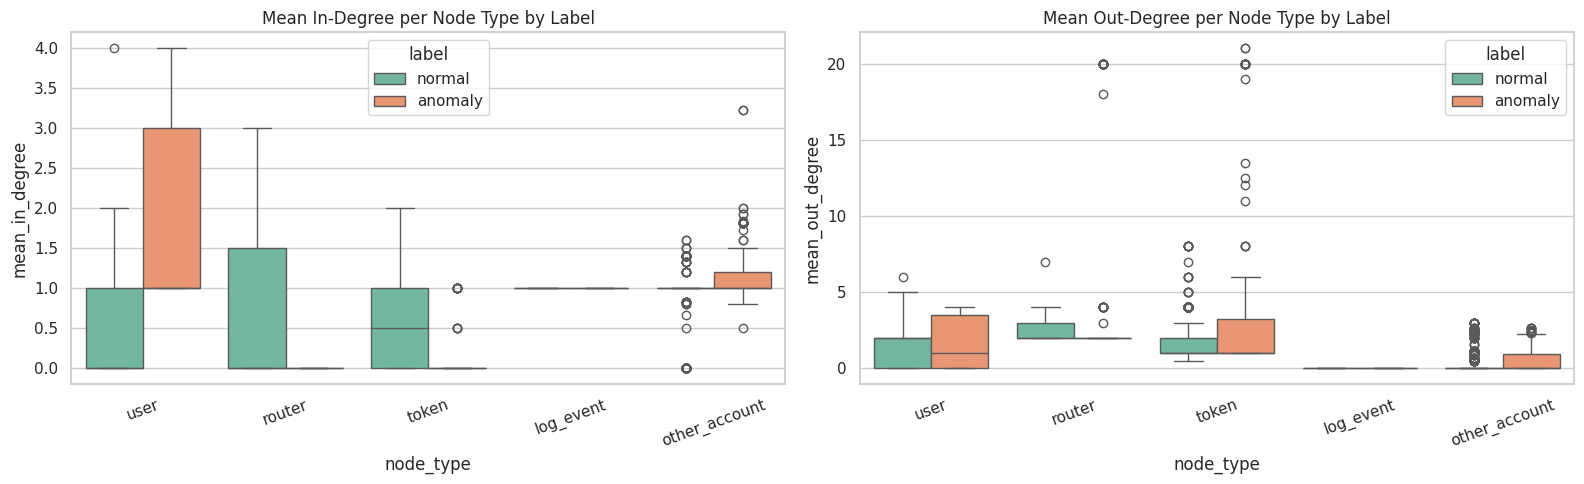

                       mean_in_degree  mean_out_degree
label   node_type                                     
anomaly log_event               1.000            0.000
        other_account           1.191            0.654
        router                  0.000            4.765
        token                   0.073            4.723
        user                    1.933            1.800
normal  log_event               1.000            0.000
        other_account           0.957            0.314
        router                  0.674            2.475
        token                   0.643            1.586
        user                    0.402            1.527


In [14]:
degree_records = []
for i in range(len(dataset)):
    data = dataset[i]
    label_str = getattr(data, "y_str", "")
    for nt in ALL_NODE_TYPES:
        if nt not in data.node_types:
            continue
        x = data[nt].x
        if x.numel() == 0:
            continue
        degree_records.append({
            "label": label_str,
            "node_type": nt,
            "mean_in_degree": x[:, IN_DEGREE_INDEX].mean().item(),
            "mean_out_degree": x[:, OUT_DEGREE_INDEX].mean().item(),
            "max_in_degree": x[:, IN_DEGREE_INDEX].max().item(),
            "max_out_degree": x[:, OUT_DEGREE_INDEX].max().item(),
        })

deg_df = pd.DataFrame(degree_records)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, title in [
    (axes[0], "mean_in_degree", "Mean In-Degree"),
    (axes[1], "mean_out_degree", "Mean Out-Degree"),
]:
    sns.boxplot(data=deg_df, x="node_type", y=col, hue="label", ax=ax, palette="Set2")
    ax.set_title(f"{title} per Node Type by Label")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print(deg_df.groupby(["label", "node_type"])[["mean_in_degree", "mean_out_degree"]].mean().round(3))

- User nodes have usually higher in-degrees in anomalous cases compared to normal cases
- Router node in-degrees are usually 1 unit higher in normal cases compared to anomalous cases (which are almost all zero). Same for token nodes, which have almost zero in-degrees in anomalous cases, but a wider distribution in normal cases.

## 7. Edge Type Distribution by Label

Mean edge count per relation per graph:
            transaction  token_transfer  token_auth  function_call  \
label_str                                                           
anomaly           0.00            5.81        0.06           0.09   
normal            0.46            1.69        0.14           0.98   

           log_relation  cross_chain_relation  
label_str                                      
anomaly            8.78                  0.00  
normal             3.87                  0.35  


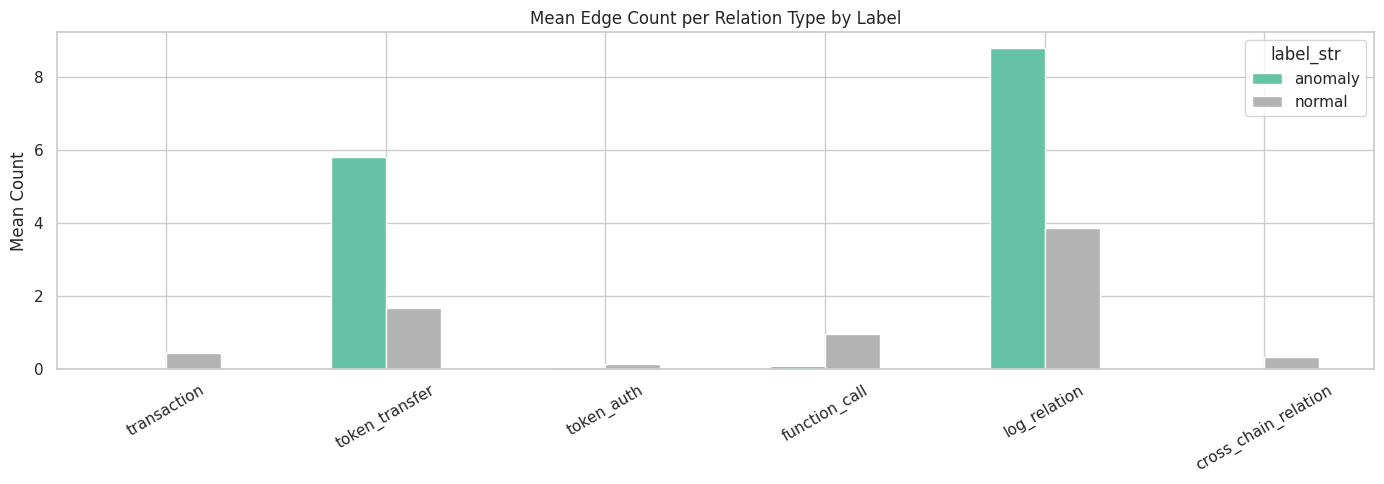


Fraction of cross_chain_relation edges per label:
            count   mean    std  min  25%  50%  75%    max
label_str                                                 
anomaly     166.0  0.000  0.000  0.0  0.0  0.0  0.0  0.000
normal     1951.0  0.027  0.059  0.0  0.0  0.0  0.0  0.182


In [13]:
edge_rel_cols = [f"e_{r}" for r in ALL_EDGE_RELS]
edge_by_label = stats_df.groupby("label_str")[edge_rel_cols].mean()
edge_by_label.columns = ALL_EDGE_RELS
print("Mean edge count per relation per graph:\n", edge_by_label.round(2))

edge_by_label.T.plot(kind="bar", figsize=(14, 5), colormap="Set2")
plt.title("Mean Edge Count per Relation Type by Label")
plt.ylabel("Mean Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

stats_df["frac_cross_chain"] = stats_df["e_cross_chain_relation"] / stats_df["total_edges"].clip(lower=1)
print("\nFraction of cross_chain_relation edges per label:")
print(stats_df.groupby("label_str")["frac_cross_chain"].describe().round(3))

## 8. Duplicate / Near-Duplicate Detection

In [14]:
dup_key = list(zip(
    stats_df["bridge"],
    stats_df["total_nodes"],
    stats_df["total_edges"],
    stats_df["label_int"],
))
stats_df["_dup_key"] = dup_key
key_counts = stats_df["_dup_key"].value_counts()
dup_keys = key_counts[key_counts > 1]

print(f"Distinct (bridge, #nodes, #edges, label) combos : {len(key_counts)}")
print(f"Combos with >1 match (suspected near-duplicates): {len(dup_keys)}")
print(f"Total graphs in duplicated groups               : {dup_keys.sum()}")

if len(dup_keys):
    print("\nTop 10 most-duplicated keys:")
    print(dup_keys.head(10))
    top_key = dup_keys.index[0]
    example_idxs = stats_df[stats_df["_dup_key"] == top_key]["idx"].tolist()
    print(f"\nExample group key={top_key}, graph indices: {example_idxs[:5]}")

stats_df.drop(columns=["_dup_key"], inplace=True)

Distinct (bridge, #nodes, #edges, label) combos : 101
Combos with >1 match (suspected near-duplicates): 61
Total graphs in duplicated groups               : 2077

Top 10 most-duplicated keys:
_dup_key
(nomad, 5, 3, 0)         679
(nomad, 8, 9, 0)         213
(omnibridge, 7, 6, 0)    156
(omnibridge, 7, 7, 0)    139
(ronin, 14, 14, 0)       112
(ronin, 11, 11, 0)       102
(nomad, 5, 3, 1)          84
(nomad, 8, 6, 0)          49
(nomad, 22, 19, 0)        40
(nomad, 6, 6, 0)          35
Name: count, dtype: int64

Example group key=('nomad', 5, 3, 0), graph indices: [462, 463, 464, 466, 467]


## 9. Structural Outliers

In [16]:
p01 = stats_df["total_nodes"].quantile(0.01)
p99 = stats_df["total_nodes"].quantile(0.99)
outliers = stats_df[(stats_df["total_nodes"] <= p01) | (stats_df["total_nodes"] >= p99)]

print(f"Node count 1st pct = {p01:.0f}, 99th pct = {p99:.0f}")
print(f"Outlier graphs: {len(outliers)}")
print("\nLabel distribution in outliers:")
print(outliers["label_str"].value_counts())
print("\nBridge distribution in outliers:")
print(outliers["bridge"].value_counts())

print("\nOutlier rate by label:")
for lbl, grp in stats_df.groupby("label_str"):
    rate = ((grp["total_nodes"] <= p01) | (grp["total_nodes"] >= p99)).mean()
    print(f"  {lbl:10s}: {rate:.1%}")

print("\nTop 5 graphs by node count:")
print(stats_df.nlargest(5, "total_nodes")[
    ["idx", "label_str", "bridge", "graph_type", "total_nodes", "total_edges"]
])

empty = stats_df[stats_df["total_nodes"] == 0]
print(f"\nCompletely empty graphs (0 nodes): {len(empty)}")
if len(empty):
    print(empty[["idx", "label_str", "bridge", "graph_type"]])

Node count 1st pct = 5, 99th pct = 43
Outlier graphs: 828

Label distribution in outliers:
label_str
normal     720
anomaly    108
Name: count, dtype: int64

Bridge distribution in outliers:
bridge
nomad         794
ronin          32
omnibridge      2
Name: count, dtype: int64

Outlier rate by label:
  anomaly   : 65.1%
  normal    : 36.9%

Top 5 graphs by node count:
       idx label_str bridge    graph_type  total_nodes  total_edges
678    678   anomaly  nomad  single_chain           68           94
785    785   anomaly  nomad  single_chain           68           94
1879  1879    normal  ronin   cross_chain           61           60
691    691   anomaly  nomad  single_chain           45           55
680    680   anomaly  nomad  single_chain           43           50

Completely empty graphs (0 nodes): 2
     idx label_str      bridge    graph_type
24    24    normal  omnibridge  single_chain
447  447    normal  omnibridge  single_chain


## 10. Differential Metapath Feature Analysis

- **Viz 1 (frequency)**: Are certain structural paths traversed more in anomaly graphs?
- **Viz 2 (L2 norm)**: Is the aggregated feature *signal strength* along each metapath different between labels?
- **Viz 3 (PCA)**: Do the combined metapath features form separable clusters? Is separation is driven by the anomaly signal or by bridge identity?

In [7]:
# Perform Differential Meta-path Extraction on the training/validation set
# to identify the most discriminative meta-paths for the classification task
from dataset_generator.model_training import aggregate_metapath_features, differential_metapath_extraction

metapaths = differential_metapath_extraction(dataset, threshold=0.5, max_hops=5)
print(f"Identified {len(metapaths)} differential metapaths.")
base_feature_dims: dict = {}
for data in dataset:
    for node_type in data.node_types:
        if not hasattr(data[node_type], "x") or data[node_type].x is None:
            continue
        dim = int(data[node_type].x.size(1))
        if node_type in base_feature_dims and base_feature_dims[node_type] != dim:
            raise ValueError(f"Inconsistent feature dim for '{node_type}': {base_feature_dims[node_type]} vs {dim}")
        base_feature_dims[node_type] = dim

expected_node_types = sorted(base_feature_dims.keys())
# Expected end-node feature dim for each metapath (used later for zero-padding)
mp_end_dims = {mp: base_feature_dims.get(mp[-1][2], 1) for mp in metapaths}

mp_records = []
for i in range(len(dataset)):
    data = dataset[i]
    agg_feats, _ = aggregate_metapath_features(
        data,
        metapaths,
        expected_node_types=expected_node_types,
        base_feature_dims=base_feature_dims,
    )
    mp_records.append({
        "label":      getattr(data, "y_str", ""),
        "graph_type": getattr(data, "graph_type", "unknown"),
        "bridge":     getattr(data, "bridge", "unknown"),
        "agg_feats":  agg_feats,
    })

def mp_label(mp):
    """Short human-readable string for a metapath."""
    return "\n".join(f"{s}–[{r}]→{t}" for s, r, t in mp)

Identified 16 differential metapaths.


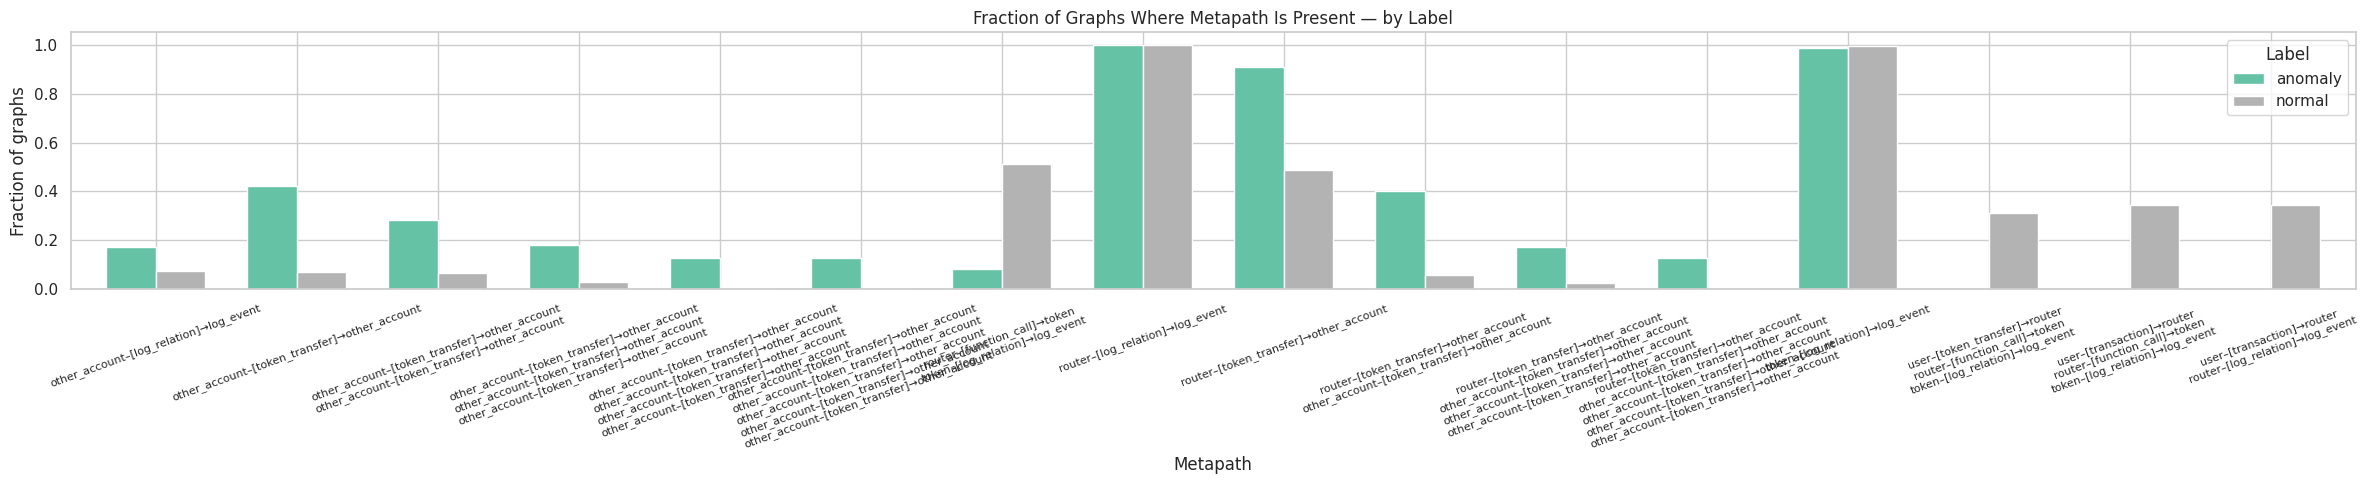

label                                               anomaly  normal
metapath                                                           
other_account–[log_relation]→log_event                0.175   0.074
other_account–[token_transfer]→other_account          0.422   0.072
other_account–[token_transfer]→other_account\no...    0.283   0.066
other_account–[token_transfer]→other_account\no...    0.181   0.029
other_account–[token_transfer]→other_account\no...    0.127   0.006
other_account–[token_transfer]→other_account\no...    0.127   0.006
router–[function_call]→token\ntoken–[log_relati...    0.084   0.512
router–[log_relation]→log_event                       1.000   0.999
router–[token_transfer]→other_account                 0.910   0.489
router–[token_transfer]→other_account\nother_ac...    0.404   0.059
router–[token_transfer]→other_account\nother_ac...    0.175   0.028
router–[token_transfer]→other_account\nother_ac...    0.127   0.006
token–[log_relation]→log_event                  

In [8]:
freq_rows = []
for rec in mp_records:
    for mp in metapaths:
        feat = rec["agg_feats"].get(mp)
        present = int(feat is not None and feat.numel() > 0 and feat.norm().item() > 0)
        freq_rows.append({"label": rec["label"], "metapath": mp_label(mp), "present": present})

freq_df = pd.DataFrame(freq_rows)
freq_pivot = freq_df.groupby(["metapath", "label"])["present"].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(max(10, len(metapaths) * 1.5), 5))
freq_pivot.plot(kind="bar", ax=ax, colormap="Set2", width=0.7)
ax.set_title("Fraction of Graphs Where Metapath Is Present — by Label")
ax.set_ylabel("Fraction of graphs")
ax.set_xlabel("Metapath")
ax.tick_params(axis="x", rotation=20, labelsize=8)
ax.legend(title="Label")
plt.tight_layout()
plt.show()

print(freq_pivot.round(3))

A large gap between bars for the same metapath confirms the extraction worked. If all bars are near-identical, the threshold was too low and these metapaths have no real discriminative value.

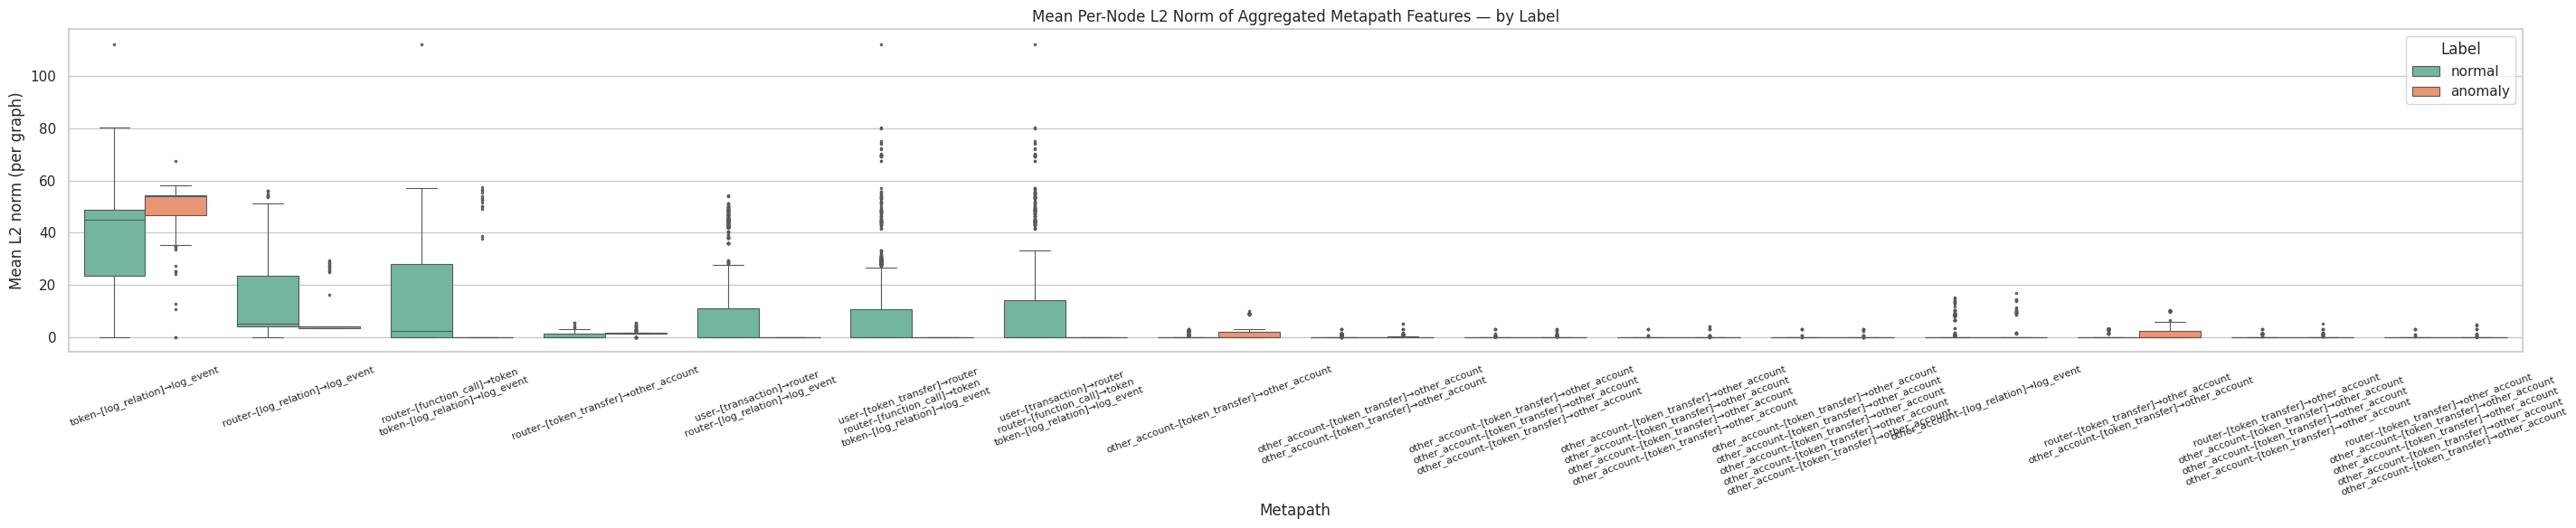

                                                             count     mean  \
label   metapath                                                              
anomaly other_account–[log_relation]→log_event               166.0   1.5194   
        other_account–[token_transfer]→other_account         166.0   2.0170   
        other_account–[token_transfer]→other_account\no...   166.0   0.3516   
        other_account–[token_transfer]→other_account\no...   166.0   0.2148   
        other_account–[token_transfer]→other_account\no...   166.0   0.1757   
        other_account–[token_transfer]→other_account\no...   166.0   0.1406   
        router–[function_call]→token\ntoken–[log_relati...   166.0   4.3113   
        router–[log_relation]→log_event                      166.0   5.9599   
        router–[token_transfer]→other_account                166.0   1.7516   
        router–[token_transfer]→other_account\nother_ac...   166.0   2.1719   
        router–[token_transfer]→other_account\nother

In [9]:
norm_rows = []
for rec in mp_records:
    for mp in metapaths:
        feat = rec["agg_feats"].get(mp)
        if feat is None or feat.numel() == 0:
            norm_val = 0.0
        else:
            norm_val = feat.norm(dim=1).mean().item()
        norm_rows.append({"label": rec["label"], "metapath": mp_label(mp), "mean_l2": norm_val})

norm_df = pd.DataFrame(norm_rows)

fig, ax = plt.subplots(figsize=(max(10, len(metapaths) * 1.8), 6))
sns.boxplot(
    data=norm_df, x="metapath", y="mean_l2", hue="label",
    ax=ax, palette="Set2", fliersize=1.5, linewidth=0.8,
)
ax.set_title("Mean Per-Node L2 Norm of Aggregated Metapath Features — by Label")
ax.set_ylabel("Mean L2 norm (per graph)")
ax.set_xlabel("Metapath")
ax.tick_params(axis="x", rotation=20, labelsize=8)
ax.legend(title="Label")
plt.tight_layout()
plt.show()

# Numeric summary
print(norm_df.groupby(["label", "metapath"])["mean_l2"].describe().round(4))

Boxes that don't overlap are strong evidence the metapath carries a discriminative signal.

Total PCA variance explained: 45.0%


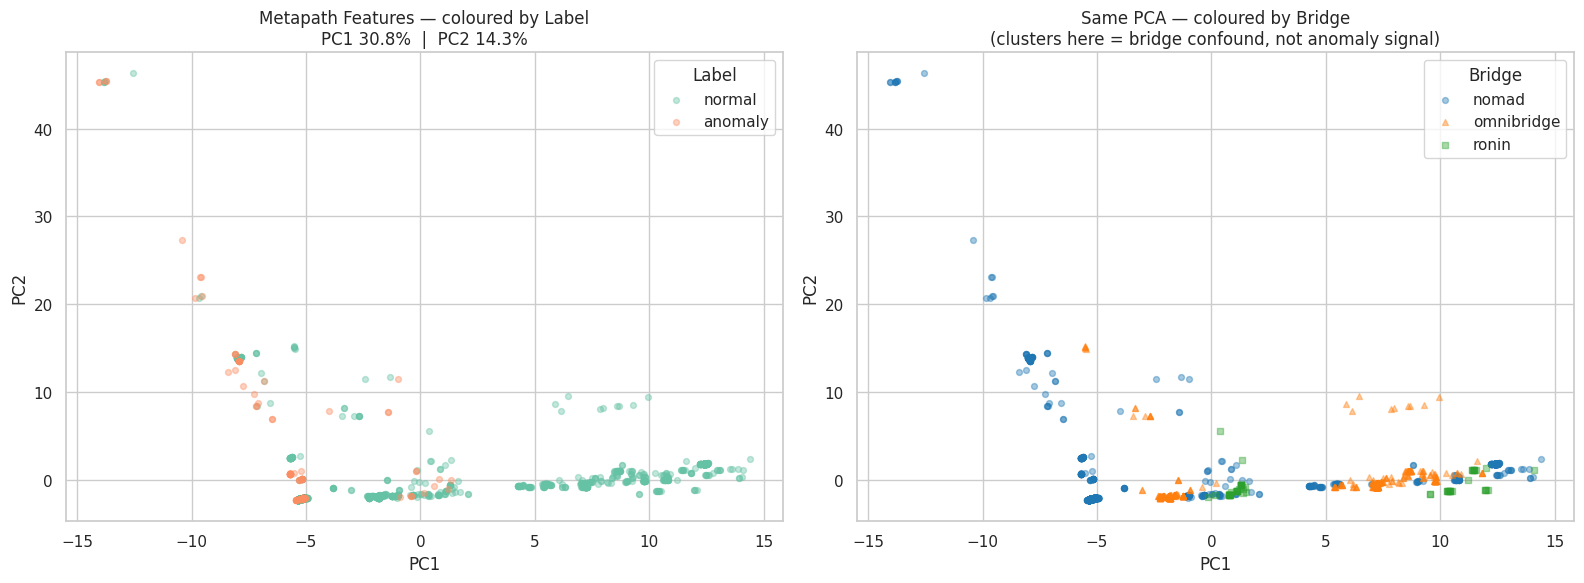

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Build per-graph vector: concatenate mean feature for each metapath
feature_vecs, meta = [], []
for rec in mp_records:
    vecs = []
    for mp in metapaths:
        feat = rec["agg_feats"].get(mp)
        dim = mp_end_dims[mp]
        if feat is None or feat.numel() == 0:
            vecs.append(np.zeros(dim, dtype=np.float32))
        else:
            vecs.append(feat.mean(dim=0).numpy())
    feature_vecs.append(np.concatenate(vecs))
    meta.append({"label": rec["label"], "bridge": rec["bridge"]})

X = np.nan_to_num(np.stack(feature_vecs))
pca_df = pd.DataFrame(meta)

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
pca_df["PC1"], pca_df["PC2"] = X_2d[:, 0], X_2d[:, 1]
print(f"Total PCA variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: coloured by label
unique_labels = sorted(pca_df["label"].unique(), reverse=True)
pal_lbl = dict(zip(unique_labels, sns.color_palette("Set2", len(unique_labels))))
for lbl in unique_labels:
    sub = pca_df[pca_df["label"] == lbl]
    axes[0].scatter(sub["PC1"], sub["PC2"], alpha=0.4, s=18, label=lbl, color=pal_lbl[lbl])
axes[0].set_title(
    f"Metapath Features — coloured by Label\n"
    f"PC1 {pca.explained_variance_ratio_[0]*100:.1f}%  |  PC2 {pca.explained_variance_ratio_[1]*100:.1f}%"
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title="Label")

# Right: coloured by bridge  ← the confound check
unique_bridges = sorted(pca_df["bridge"].unique())
pal_br = dict(zip(unique_bridges, sns.color_palette("tab10", len(unique_bridges))))
markers = ["o", "^", "s", "D", "v", "P"]
for i, br in enumerate(unique_bridges):
    sub = pca_df[pca_df["bridge"] == br]
    axes[1].scatter(sub["PC1"], sub["PC2"], alpha=0.4, s=18, label=br,
                    color=pal_br[br], marker=markers[i % len(markers)])
axes[1].set_title("Same PCA — coloured by Bridge\n(clusters here = bridge confound, not anomaly signal)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title="Bridge")

plt.tight_layout()
plt.show()

**Left:** If normal and anomaly points form distinct, non-overlapping regions the metapath features are discriminative

**Right:** If the same cluster boundaries match the bridge boundaries instead of the label boundaries, the model will learn discrepancies in bridge characteristics, not anomaly signal.